# LFM 信号仿真基础

目标：先生成一个单分量 LFM（Linear Frequency Modulation，线性调频）信号，观察它的时域波形、瞬时频率、频谱和时频图，为后续宽带 DOA / FRFT 处理做准备。

本实验参数：

- 初始频率 `f0 = 15 kHz`
- 调频斜率 `mu = 7500 kHz/s = 7.5e6 Hz/s`
- 采样频率 `fs = 500 kHz`
- 信号模型：$s(t)=A\exp(j2\pi(f_0 t + \frac{1}{2}\mu t^2) + j\phi)$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["DejaVu Sans", "SimSun"]
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimSun"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 参数说明

LFM 的瞬时频率为：

$f(t)=f_0+\mu t$

如果取采样点数 `N = 1000`，在 `fs = 500 kHz` 下，信号时长为：

$T=N/f_s=1000/500000=2 ms$

此时终止频率为：

$f_1=f_0+\mu T=15 kHz+7.5 MHz/s \times 2 ms=30 kHz$

所以这个 LFM 信号频率从 `15 kHz` 线性扫到约 `30 kHz`。

In [2]:
# -----------------------------
# 1. LFM 参数
# -----------------------------
A = 1.0
f0 = 15e3                 # 初始频率，Hz
mu = 7500e3               # 调频斜率，Hz/s，也就是 7500 kHz/s
phi = 0.0                 # 初始相位，rad
fs = 500e3                # 采样频率，Hz
N = 1000                  # 采样点数

t = np.arange(N) / fs
duration = N / fs
instantaneous_freq = f0 + mu * t

# 复解析 LFM 信号，适合后续阵列/DOA 处理。
phase = 2 * np.pi * (f0 * t + 0.5 * mu * t**2) + phi
s = A * np.exp(1j * phase)

# 真实传感器常测到实信号，这里用 real(s) 做时域展示。
s_real = np.real(s)

print(f"f0 = {f0 / 1e3:.1f} kHz")
print(f"mu = {mu / 1e3:.1f} kHz/s")
print(f"fs = {fs / 1e3:.1f} kHz")
print(f"N = {N}, duration = {duration * 1e3:.2f} ms")
print(f"start frequency = {instantaneous_freq[0] / 1e3:.2f} kHz")
print(f"end frequency = {instantaneous_freq[-1] / 1e3:.2f} kHz")


f0 = 15.0 kHz
mu = 7500.0 kHz/s
fs = 500.0 kHz
N = 1000, duration = 2.00 ms
start frequency = 15.00 kHz
end frequency = 29.98 kHz


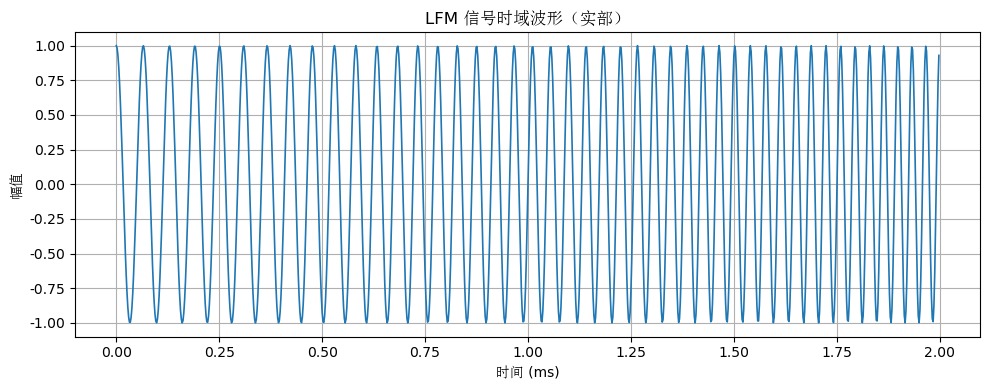

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(t * 1e3, s_real, linewidth=1.2)
plt.xlabel("时间 (ms)")
plt.ylabel("幅值")
plt.title("LFM 信号时域波形（实部）")
plt.tight_layout()


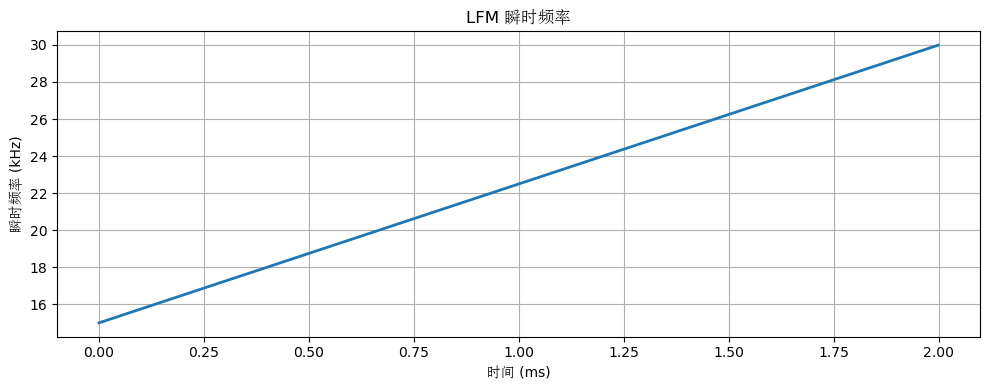

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t * 1e3, instantaneous_freq / 1e3, linewidth=2)
plt.xlabel("时间 (ms)")
plt.ylabel("瞬时频率 (kHz)")
plt.title("LFM 瞬时频率")
plt.tight_layout()

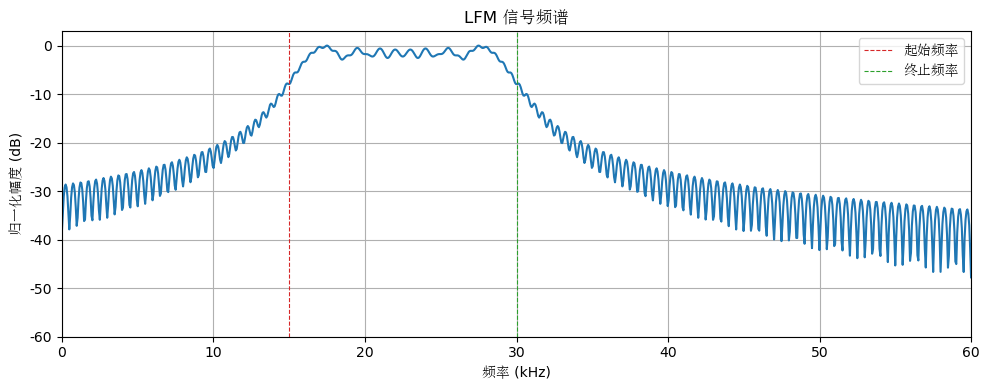

In [5]:
# 使用零填充提高频谱显示的平滑程度。
nfft = 8192
freq = np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / fs))
S_fft = np.fft.fftshift(np.fft.fft(s, n=nfft))
S_fft_db = 20 * np.log10(np.maximum(np.abs(S_fft), np.finfo(float).tiny) / np.max(np.abs(S_fft)))

plt.figure(figsize=(10, 4))
plt.plot(freq / 1e3, S_fft_db, linewidth=1.5)
plt.axvline(f0 / 1e3, color="tab:red", linestyle="--", linewidth=0.8, label="起始频率")
plt.axvline((f0 + mu * duration) / 1e3, color="tab:green", linestyle="--", linewidth=0.8, label="终止频率")
plt.xlim(0, 60)
plt.ylim(-60, 3)
plt.xlabel("频率 (kHz)")
plt.ylabel("归一化幅度 (dB)")
plt.title("LFM 信号频谱")
plt.legend(loc="upper right")
plt.tight_layout()


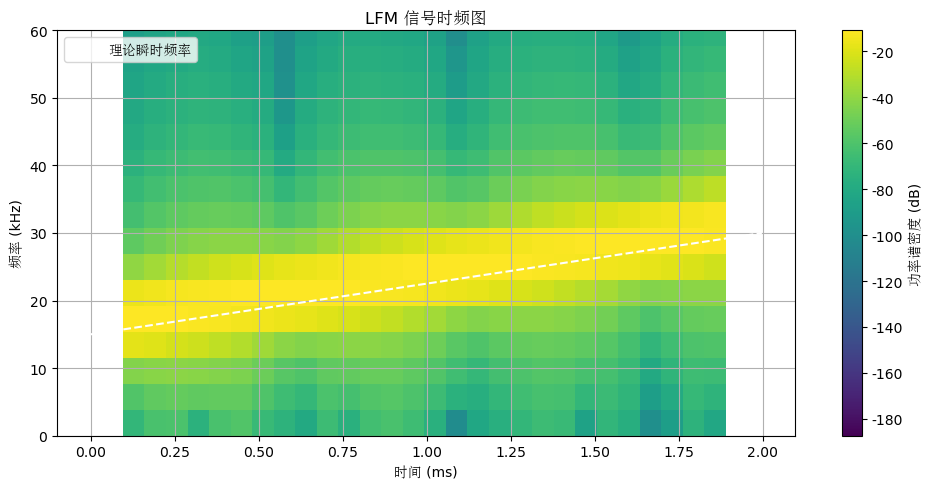

In [6]:
# spectrogram 用实信号展示，更接近传感器采样后的直观时频图。
plt.figure(figsize=(10, 5))
Pxx, freqs, bins, im = plt.specgram(
    s_real,
    NFFT=128,
    Fs=fs / 1e3,   # 变成 kHz，对应时间轴就是 ms
    noverlap=96,
    cmap="viridis",
)
plt.plot(t * 1e3, instantaneous_freq / 1e3, color="white", linestyle="--", linewidth=1.5, label="理论瞬时频率")
plt.ylim(0, 60)
plt.xlabel("时间 (ms)")
plt.ylabel("频率 (kHz)")
plt.title("LFM 信号时频图")
plt.colorbar(im).set_label("功率谱密度 (dB)")
plt.legend(loc="upper left")
plt.tight_layout()


# FRFT 与 LFM DOA：从聚焦到方位估计

这一部分重新按一条主线组织：

1. 先看 FRFT 为什么能聚焦 LFM。
2. 再用阶次扫描找最适合当前 LFM 的 FRFT 阶次。
3. 然后实现两种 FRFT-CBF：
   - **宽带延时求和 + FRFT**：先按候选角对齐阵元信号，再做 FRFT 取聚焦能量。
   - **参考文献中的 FRF 域 CBF**：每个阵元先做 FRFT，在聚焦 bin 处构造阵列快照，再用 $a^H R a$ 扫描空间谱。

这里的代码优先保持概念清楚和可验证。FRFT 采用直接矩阵形式，适合教学与小规模仿真；如果后续做大规模实验，再换成快速 FRFT 实现。


## 1. FRFT 为什么能聚焦 LFM

LFM 信号的复解析形式是：

$$
s(t)=A\exp\left[j2\pi\left(f_0t+\frac{1}{2}\mu t^2\right)+j\phi\right]
$$

它的瞬时频率为：

$$
f(t)=f_0+\mu t
$$

所以 LFM 在时频平面里是一条斜线。普通 Fourier 变换相当于把信号投影到频率轴；FRFT 可以理解为把时频坐标轴旋转一个角度后再观察信号。

FRFT 阶次 $p$ 与旋转角的关系是：

$$
\alpha=p\frac{\pi}{2}
$$

其核函数可写成：

$$
K_\alpha(t,u)=A_\alpha
\exp\left[
j\pi\left(t^2\cot\alpha-2tu\csc\alpha+u^2\cot\alpha\right)
\right]
$$

它同样含有二次相位项。当 FRFT 阶次与 LFM 调频斜率匹配时，原本分散在一条斜线上的 LFM 能量会在分数阶域里被压缩到少数 bin 附近。

简单说：**FFT 是找固定频率的能量，FRFT 是找某个 chirp 斜率上的能量。**


In [ ]:
# -----------------------------
# FRFT helper functions
# -----------------------------
def dft_unitary(x):
    """Unitary DFT with centered frequency bins."""
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))) / np.sqrt(len(x))


def idft_unitary(x):
    """Unitary inverse DFT with centered bins."""
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(x))) * np.sqrt(len(x))


def frft_matrix_direct(N_local, p):
    """Direct DFRFT matrix used by this notebook.

    The sample coordinates are dimensionless and centered. This convention is
    pedagogical; all later steering/manifold calculations are built with the
    same matrix so the phase convention stays self-consistent.
    """
    p_mod = np.mod(p, 4.0)
    if np.isclose(p_mod, 0.0):
        return np.eye(N_local, dtype=complex)
    if np.isclose(p_mod, 1.0):
        eye = np.eye(N_local, dtype=complex)
        return np.column_stack([dft_unitary(eye[:, k]) for k in range(N_local)])
    if np.isclose(p_mod, 2.0):
        return np.eye(N_local, dtype=complex)[::-1]
    if np.isclose(p_mod, 3.0):
        eye = np.eye(N_local, dtype=complex)
        return np.column_stack([idft_unitary(eye[:, k]) for k in range(N_local)])

    alpha = p_mod * np.pi / 2
    sin_alpha = np.sin(alpha)
    cot_alpha = 1 / np.tan(alpha)
    csc_alpha = 1 / sin_alpha

    n = np.arange(N_local) - (N_local - 1) / 2
    t_norm = n / np.sqrt(N_local)
    u_norm = n / np.sqrt(N_local)
    T, U = np.meshgrid(t_norm, u_norm, indexing="ij")
    phase = np.pi * (T**2 * cot_alpha - 2 * T * U * csc_alpha + U**2 * cot_alpha)
    kernel = np.exp(1j * phase)
    return kernel.conj().T / np.sqrt(N_local * abs(sin_alpha))


def frft_direct(x, p):
    """Apply the direct DFRFT matrix."""
    x = np.asarray(x, dtype=complex)
    return frft_matrix_direct(x.size, p) @ x


def normalized_db(power_like):
    power_like = np.asarray(power_like)
    return 10 * np.log10(np.maximum(power_like, np.finfo(float).tiny) / np.max(power_like))


def parabolic_peak_interpolation(x_grid, y):
    """Sub-grid peak interpolation using three neighboring linear-power points."""
    idx = int(np.argmax(y))
    if idx == 0 or idx == len(y) - 1:
        return float(x_grid[idx])
    y_left, y_mid, y_right = y[idx - 1], y[idx], y[idx + 1]
    denom = y_left - 2 * y_mid + y_right
    if abs(denom) < np.finfo(float).eps:
        return float(x_grid[idx])
    step = float(x_grid[1] - x_grid[0])
    offset = 0.5 * (y_left - y_right) / denom
    offset = float(np.clip(offset, -1.0, 1.0))
    return float(x_grid[idx] + offset * step)


# Use a shorter segment for O(N^2) FRFT demonstrations.
frft_stride = 4
s_frft = s[::frft_stride]
t_frft = t[::frft_stride]
fs_frft = fs / frft_stride
N_frft = s_frft.size
s_frft_unit = s_frft / np.sqrt(np.sum(np.abs(s_frft) ** 2))

print("FRFT analysis segment")
print(f"N_frft = {N_frft}, fs_frft = {fs_frft / 1e3:.1f} kHz, stride = {frft_stride}")
print(f"p=0 check error = {np.linalg.norm(frft_direct(s_frft_unit, 0) - s_frft_unit):.2e}")
print(f"p=2 check error = {np.linalg.norm(frft_direct(s_frft_unit, 2) - s_frft_unit[::-1]):.2e}")


In [ ]:
# -----------------------------
# Find the FRFT order that best focuses the LFM
# -----------------------------
orders = np.linspace(0.05, 1.95, 121)
peak_to_mean = np.zeros_like(orders)
entropy = np.zeros_like(orders)

for i, p in enumerate(orders):
    Xp = frft_direct(s_frft_unit, p)
    power = np.abs(Xp) ** 2
    power = power / np.sum(power)
    peak_to_mean[i] = np.max(power) / np.mean(power)
    entropy[i] = -np.sum(power * np.log(power + np.finfo(float).tiny))

best_idx = int(np.argmax(peak_to_mean))
p_best = float(orders[best_idx])
alpha_best = p_best * np.pi / 2

print(f"Best FRFT order = {p_best:.3f}")
print(f"Best rotation angle alpha = {np.rad2deg(alpha_best):.2f} deg")
print(f"Peak-to-mean = {peak_to_mean[best_idx]:.2f}")
print(f"Entropy = {entropy[best_idx]:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(orders, peak_to_mean, linewidth=1.8)
plt.axvline(p_best, color="tab:red", linestyle="--", linewidth=1.2, label=f"best p = {p_best:.3f}")
plt.xlabel("FRFT order p")
plt.ylabel("Peak-to-mean concentration")
plt.title("FRFT order scan for LFM")
plt.legend(loc="best")
plt.tight_layout()


In [ ]:
# -----------------------------
# Compare ordinary FFT with best-order FRFT
# -----------------------------
X_fft = frft_direct(s_frft_unit, 1.0)
X_best = frft_direct(s_frft_unit, p_best)

freq_fft = np.fft.fftshift(np.fft.fftfreq(N_frft, d=1 / fs_frft)) / 1e3
u_axis = np.arange(N_frft) - (N_frft - 1) / 2

fft_mag_db = 20 * np.log10(np.maximum(np.abs(X_fft), np.finfo(float).tiny) / np.max(np.abs(X_fft)))
best_mag_db = 20 * np.log10(np.maximum(np.abs(X_best), np.finfo(float).tiny) / np.max(np.abs(X_best)))

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.plot(freq_fft, fft_mag_db, linewidth=1.4)
plt.axvline(f0 / 1e3, color="tab:red", linestyle="--", linewidth=0.8, label="start f")
plt.axvline((f0 + mu * duration) / 1e3, color="tab:green", linestyle="--", linewidth=0.8, label="end f")
plt.xlim(0, 60)
plt.ylim(-60, 3)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalized magnitude (dB)")
plt.title("FFT: energy spread over sweep band")
plt.legend(loc="upper right")

plt.subplot(1, 2, 2)
plt.plot(u_axis, best_mag_db, linewidth=1.4, color="tab:purple")
plt.ylim(-60, 3)
plt.xlabel("FRFT-domain bin")
plt.ylabel("Normalized magnitude (dB)")
plt.title(f"FRFT: focused energy, p = {p_best:.3f}")
plt.tight_layout()


## 2. 两种 FRFT-CBF 思路

### A. 宽带延时求和 + FRFT

这个版本更直观：对每个扫描角 $\theta$ 先做宽带 CBF 对齐：

$$
y_\theta(t)=\frac{1}{M}\sum_{m=0}^{M-1}x_m(t+\tau_m(\theta))
$$

ULA 的候选时延为：

$$
\tau_m(\theta)=\frac{p_m\sin\theta}{c}
$$

然后对 $y_\theta(t)$ 做 FRFT。为了更像“聚焦后的空间谱”，不让每个角度随便找自己的最大 bin，我们固定全局聚焦 bin $u_0$：

$$
P_{delay\text{-}sum}(\theta)
=\left|\mathcal F^{p_{best}}\{y_\theta(t)\}(u_0)\right|^2
$$

### B. 参考文献中的 FRF 域 CBF

参考文献的写法是：每个阵元先做 FRFT，得到分数阶域阵列快照：

$$
\mathbf X(u,\alpha)=
\begin{bmatrix}
X_0(u,\alpha) & X_1(u,\alpha) & \cdots & X_{M-1}(u,\alpha)
\end{bmatrix}^T
$$

然后仿照窄带 CBF：

$$
y(u,\alpha,\theta)=\mathbf a^H(u,\alpha,\theta)\mathbf X(u,\alpha)
$$

$$
P_{FRF\text{-}CBF}(\theta)
=\mathbf a^H(u,\alpha,\theta)\mathbf R(u,\alpha)\mathbf a(u,\alpha,\theta)
$$

其中：

$$
\mathbf R(u,\alpha)=E[\mathbf X(u,\alpha)\mathbf X^H(u,\alpha)]
$$

样本有限时可以在聚焦峰附近取几个 bin 估计：

$$
\hat{\mathbf R}
=\frac{1}{L}\sum_{\ell=1}^{L}
\mathbf X(u_\ell,\alpha)\mathbf X^H(u_\ell,\alpha)
$$

要注意：FRFT 域的延时响应不是简单的 $e^{-j2\pi f_c\tau}$。它会涉及分数阶坐标偏移和二次相位。所以代码里不直接套普通窄带 steering vector，而是用与当前 DFRFT 实现一致的**校准阵列流形**来构造 $\mathbf a(u,\alpha,\theta)$。


In [ ]:
# -----------------------------
# ULA LFM array simulation
# -----------------------------
c_lfm = 1500.0
M_lfm = 16
d_lfm = 0.025
positions_lfm = np.arange(M_lfm) * d_lfm

theta_true_lfm_deg = 25.0
snr_lfm_db = 20.0


def analytic_lfm_at(t_eval):
    """Evaluate the finite-duration analytic LFM at arbitrary times."""
    t_eval = np.asarray(t_eval)
    y = np.zeros(t_eval.shape, dtype=complex)
    inside = (t_eval >= 0.0) & (t_eval < duration)
    phase_eval = 2 * np.pi * (f0 * t_eval[inside] + 0.5 * mu * t_eval[inside] ** 2) + phi
    y[inside] = A * np.exp(1j * phase_eval)
    return y


def add_complex_awgn_matrix(X_clean, snr_db, seed=0):
    rng = np.random.default_rng(seed)
    signal_power = np.mean(np.abs(X_clean) ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(X_clean.shape) + 1j * rng.standard_normal(X_clean.shape)
    )
    return X_clean + noise


def interp_complex_1d(t_axis, x, t_query):
    """Linear interpolation for complex-valued sampled data."""
    real = np.interp(t_query, t_axis, np.real(x), left=0.0, right=0.0)
    imag = np.interp(t_query, t_axis, np.imag(x), left=0.0, right=0.0)
    return real + 1j * imag


theta_true_rad = np.deg2rad(theta_true_lfm_deg)
tau_true = positions_lfm * np.sin(theta_true_rad) / c_lfm
X_lfm_clean = np.vstack([analytic_lfm_at(t - tau_m) for tau_m in tau_true])
X_lfm = add_complex_awgn_matrix(X_lfm_clean, snr_db=snr_lfm_db, seed=2026)

scan_angles_frft_cbf = np.arange(-60.0, 60.0 + 0.05, 0.1)
max_scan_delay = np.max(np.abs(positions_lfm)) * np.sin(np.deg2rad(np.max(np.abs(scan_angles_frft_cbf)))) / c_lfm
t_cbf_all = t[::frft_stride]
valid_cbf = (t_cbf_all >= max_scan_delay) & (t_cbf_all <= duration - max_scan_delay)
t_cbf = t_cbf_all[valid_cbf]
N_cbf = t_cbf.size

# Re-estimate best FRFT order on the exact CBF time window.
s_cbf_ref = analytic_lfm_at(t_cbf)
s_cbf_ref = s_cbf_ref / np.sqrt(np.sum(np.abs(s_cbf_ref) ** 2))
cbf_order_metric = np.zeros_like(orders)
for i_order, p in enumerate(orders):
    Xp_ref = frft_direct(s_cbf_ref, p)
    power_ref = np.abs(Xp_ref) ** 2
    power_ref = power_ref / np.sum(power_ref)
    cbf_order_metric[i_order] = np.max(power_ref) / np.mean(power_ref)

p_cbf_best = float(orders[int(np.argmax(cbf_order_metric))])
F_cbf_best = frft_matrix_direct(N_cbf, p_cbf_best)

print("FRFT-CBF array simulation")
print(f"M = {M_lfm}, d = {d_lfm:.4f} m")
print(f"true DOA = {theta_true_lfm_deg:.1f} deg, SNR = {snr_lfm_db:.1f} dB")
print(f"CBF valid samples = {N_cbf}, guard = {max_scan_delay * 1e6:.2f} us")
print(f"full-pulse p_best = {p_best:.3f}, CBF-window p_best = {p_cbf_best:.3f}")


In [ ]:
# -----------------------------
# Method A: delay-sum first, then FRFT focused-bin power
# -----------------------------
delay_sum_frft_matrix = np.zeros((scan_angles_frft_cbf.size, N_cbf))

for i, theta_deg in enumerate(scan_angles_frft_cbf):
    theta_rad = np.deg2rad(theta_deg)
    tau_scan = positions_lfm * np.sin(theta_rad) / c_lfm

    aligned_sum = np.zeros(N_cbf, dtype=complex)
    for m in range(M_lfm):
        aligned_sum += interp_complex_1d(t, X_lfm[m], t_cbf + tau_scan[m])

    beam_output = aligned_sum / M_lfm
    beam_frft = F_cbf_best @ beam_output
    delay_sum_frft_matrix[i] = np.abs(beam_frft) ** 2

# Diagnostic spectrum: each angle chooses its strongest FRFT bin.
delay_sum_maxbin_power = np.max(delay_sum_frft_matrix, axis=1)

# Focused spectrum: all angles are compared at one global focused bin.
global_angle_index, global_focus_bin = np.unravel_index(
    np.argmax(delay_sum_frft_matrix),
    delay_sum_frft_matrix.shape,
)
delay_sum_focused_power = delay_sum_frft_matrix[:, global_focus_bin]

theta_hat_delay_sum_grid = float(scan_angles_frft_cbf[np.argmax(delay_sum_focused_power)])
theta_hat_delay_sum = parabolic_peak_interpolation(scan_angles_frft_cbf, delay_sum_focused_power)

print("Method A: delay-sum + FRFT")
print(f"global focused bin = {global_focus_bin}")
print(f"grid estimate = {theta_hat_delay_sum_grid:.2f} deg")
print(f"interpolated estimate = {theta_hat_delay_sum:.2f} deg")
print(f"absolute error = {abs(theta_hat_delay_sum - theta_true_lfm_deg):.2f} deg")

plt.figure(figsize=(10, 4.5))
plt.plot(
    scan_angles_frft_cbf,
    normalized_db(delay_sum_maxbin_power),
    color="tab:blue",
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    label="max over FRFT bins",
)
plt.plot(
    scan_angles_frft_cbf,
    normalized_db(delay_sum_focused_power),
    color="tab:red",
    linewidth=1.8,
    label="fixed focused bin",
)
plt.axvline(theta_true_lfm_deg, color="tab:green", linestyle="--", linewidth=1.2, label=f"true {theta_true_lfm_deg:.1f} deg")
plt.axvline(theta_hat_delay_sum, color="k", linestyle=":", linewidth=1.8, label=f"estimated {theta_hat_delay_sum:.2f} deg")
plt.ylim(-40, 3)
plt.xlim(scan_angles_frft_cbf[0], scan_angles_frft_cbf[-1])
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized power (dB)")
plt.title("Method A: delay-sum then FRFT")
plt.legend(loc="best")
plt.tight_layout()


In [ ]:
# -----------------------------
# Method B: paper-style FRF-domain CBF, P(theta) = a^H R a
# -----------------------------
# 1. Transform each sensor into the FRFT domain on the same valid time window.
X_frf_time = np.vstack([
    interp_complex_1d(t, X_lfm[m], t_cbf)
    for m in range(M_lfm)
])
X_frf = (F_cbf_best @ X_frf_time.T).T  # shape: (M, N_cbf)

# 2. Use a small bin group around the focused FRFT peak to estimate covariance.
frf_focus_center = int(np.argmax(np.sum(np.abs(X_frf) ** 2, axis=0)))
frf_focus_half_width = 1
frf_focus_bins = np.arange(
    max(0, frf_focus_center - frf_focus_half_width),
    min(N_cbf, frf_focus_center + frf_focus_half_width + 1),
)
F_focus = F_cbf_best[frf_focus_bins, :]
X_focus = X_frf[:, frf_focus_bins]  # shape: (M, L)


def calibrated_frf_manifold(theta_deg):
    """FRF-domain steering manifold matched to this notebook's DFRFT convention."""
    theta_rad = np.deg2rad(theta_deg)
    tau_candidate = positions_lfm * np.sin(theta_rad) / c_lfm
    A_time = np.vstack([
        analytic_lfm_at(t_cbf - tau_m)
        for tau_m in tau_candidate
    ])
    A_focus = (F_focus @ A_time.T).T  # shape: (M, L)
    norms = np.linalg.norm(A_focus, axis=0, keepdims=True)
    return A_focus / np.maximum(norms, np.finfo(float).eps)


frf_cbf_power = np.zeros(scan_angles_frft_cbf.size)

for i, theta_deg in enumerate(scan_angles_frft_cbf):
    A_focus = calibrated_frf_manifold(theta_deg)
    power_accum = 0.0
    for k in range(frf_focus_bins.size):
        a_k = A_focus[:, k]
        x_k = X_focus[:, k]
        # a^H (x x^H) a = |a^H x|^2
        power_accum += np.abs(np.vdot(a_k, x_k)) ** 2
    frf_cbf_power[i] = power_accum / frf_focus_bins.size

theta_hat_frf_grid = float(scan_angles_frft_cbf[np.argmax(frf_cbf_power)])
theta_hat_frf = parabolic_peak_interpolation(scan_angles_frft_cbf, frf_cbf_power)

print("Method B: paper-style FRF-domain CBF")
print(f"focused bin center = {frf_focus_center}, bins = {frf_focus_bins.tolist()}")
print(f"grid estimate = {theta_hat_frf_grid:.2f} deg")
print(f"interpolated estimate = {theta_hat_frf:.2f} deg")
print(f"absolute error = {abs(theta_hat_frf - theta_true_lfm_deg):.2f} deg")

plt.figure(figsize=(10, 4.5))
plt.plot(
    scan_angles_frft_cbf,
    normalized_db(delay_sum_focused_power),
    color="tab:red",
    linewidth=1.4,
    alpha=0.85,
    label="A: delay-sum + FRFT",
)
plt.plot(
    scan_angles_frft_cbf,
    normalized_db(frf_cbf_power),
    color="tab:purple",
    linewidth=1.8,
    label="B: FRF-domain CBF",
)
plt.axvline(theta_true_lfm_deg, color="tab:green", linestyle="--", linewidth=1.2, label=f"true {theta_true_lfm_deg:.1f} deg")
plt.axvline(theta_hat_frf, color="k", linestyle=":", linewidth=1.8, label=f"FRF-CBF estimated {theta_hat_frf:.2f} deg")
plt.ylim(-40, 3)
plt.xlim(scan_angles_frft_cbf[0], scan_angles_frft_cbf[-1])
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized spatial spectrum (dB)")
plt.title("FRFT-CBF methods for LFM DOA")
plt.legend(loc="best")
plt.tight_layout()


## 3. 小结

两种方法的差别可以这样记：

- **延时求和 + FRFT**：对每个角度先把阵元信号在时域对齐，再看对齐后的 LFM 在 FRFT 聚焦 bin 上有多强。
- **FRF 域 CBF**：每个阵元先做 FRFT，然后把聚焦 bin 处的阵列数据当成“分数阶域窄带快照”，用 $a^H R a$ 构造空间谱。

参考文献中的表达

$$
P_{CBF}(\theta)=a^H(u,\alpha,\theta)R(u,\alpha)a(u,\alpha,\theta)
$$

就对应第二种方法。它的好处是形式上和窄带 CBF/MVDR/MUSIC 很一致，后续要做 FRFT-MVDR 或 FRFT-MUSIC 也更容易衔接。

工程上要最小心的是 FRFT 域导向矢量 $a(u,\alpha,\theta)$。它不能简单用普通窄带的 $e^{-j2\pi f_c\tau_m}$ 替代，因为 FRFT 下的延时会带来更复杂的相位和 bin 偏移。本 notebook 用“校准流形”保证导向矢量和当前 DFRFT 实现一致。
